In [110]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

In [111]:
analytics_general = pd.read_csv(r'C:\Users\JUAN\Documents\GitHub\ANALYTICS-EMPLOYESS\Employees_raw_Data.csv.csv')

In [112]:
analytics_general.head()

,emp_name,department,join_date,salary,age,performance_rating,city,remote_work
0,Employee_1,Engineering,2018-01-01 00:00:00,60820.29,51.0,4.0,Pune,No
1,Employee_2,NaN,2018-01-08 20:04:01,48271.19,30.0,3.0,Delhi,No
2,Employee_3,HR,2018-01-16 16:08:02,98590.99,55.0,2.0,Mumbai,No
3,Employee_4,Marketing,2018-01-24 12:12:02,71410.54,56.0,3.0,Mumbai,No
4,Employee_5,Sales,2018-02-01 08:16:03,23547.43,43.0,4.0,Chennai,yes


In [113]:
analytics_general.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_name            308 non-null    object 
 1   department          295 non-null    object 
 2   join_date           308 non-null    object 
 3   salary              290 non-null    float64
 4   age                 298 non-null    float64
 5   performance_rating  291 non-null    float64
 6   city                308 non-null    object 
 7   remote_work         281 non-null    object 
dtypes: float64(3), object(5)
memory usage: 19.4+ KB


In [114]:
analytics_general['department'] = analytics_general['department'].str.capitalize()
analytics_general['department'].unique()

array(['Engineering', nan, 'Hr', 'Marketing', 'Sales', 'Finance'],
      dtype=object)

In [115]:
analytics_general['remote_work'] = analytics_general['remote_work'].str.capitalize()
analytics_general['remote_work'].unique()

array(['No', 'Yes', nan], dtype=object)

In [116]:
analytics_general = analytics_general.drop_duplicates()
analytics_general.duplicated().sum()

np.int64(0)

In [117]:
analytics_general['salary'] = analytics_general['salary'].fillna(
    analytics_general.groupby('department')['salary'].transform('median')
)

In [118]:
analytics_general['salary'].isnull().sum()

np.int64(1)

In [119]:
analytics_general[analytics_general['salary'].isnull()]

,emp_name,department,join_date,salary,age,performance_rating,city,remote_work
11,Employee_12,NaN,2018-03-28 04:44:09,NaN,38.0,3.0,Delhi,No


In [120]:
analytics_general['salary'] = analytics_general['salary'].fillna(
    analytics_general['salary'].median()
)

In [121]:
analytics_general['salary'].isnull().sum()

np.int64(0)

In [122]:
analytics_general['age'] = analytics_general['age'].fillna( analytics_general['age'].median() )
analytics_general['performance_rating'] = analytics_general['performance_rating'].fillna(
    analytics_general.groupby('department')['performance_rating'].transform('median')
)
analytics_general[['age', 'performance_rating']].isnull().sum()

age                   0
performance_rating    0
dtype: int64

In [123]:
analytics_general['department'] = analytics_general['department'].fillna('Unknown')
analytics_general['remote_work'] = analytics_general['remote_work'].fillna('Unknown')
analytics_general[['department', 'remote_work']].isnull().sum()

department     0
remote_work    0
dtype: int64

In [124]:
analytics_general.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_name            300 non-null    object 
 1   department          300 non-null    object 
 2   join_date           300 non-null    object 
 3   salary              300 non-null    float64
 4   age                 300 non-null    float64
 5   performance_rating  300 non-null    float64
 6   city                300 non-null    object 
 7   remote_work         300 non-null    object 
dtypes: float64(3), object(5)
memory usage: 21.1+ KB


In [125]:
analytics_general['join_date'] = pd.to_datetime(analytics_general['join_date'])
analytics_general['tenure_years'] = (pd.Timestamp.now() - analytics_general['join_date']).dt.days / 365
analytics_general[['join_date', 'tenure_years']].head

<bound method NDFrame.head of               join_date  tenure_years
0   2018-01-01 00:00:00      8.772603
1   2018-01-08 20:04:01      8.750685
2   2018-01-16 16:08:02      8.731507
3   2018-01-24 12:12:02      8.709589
4   2018-02-01 08:16:03      8.687671
..                  ...           ...
295 2024-04-30 15:43:57      2.441096
296 2024-05-08 11:47:58      2.419178
297 2024-05-16 07:51:58      2.397260
298 2024-05-24 03:55:59      2.375342
299 2024-06-01 00:00:00      2.353425

[300 rows x 2 columns]>

In [126]:
analytics_general['riesgo_antiguedad'] = analytics_general['tenure_years'] < 1
analytics_general['riesgo_desempeno'] = analytics_general['performance_rating'] <= 2
analytics_general['mediana_dept'] = analytics_general.groupby('department')['salary'].transform('median')
analytics_general['riesgo_salario'] = analytics_general['salary'] < analytics_general['mediana_dept']
analytics_general[['riesgo_antiguedad', 'riesgo_desempeno', 'riesgo_salario']].sum()

riesgo_antiguedad      0
riesgo_desempeno      45
riesgo_salario       141
dtype: int64

In [127]:
analytics_general['riesgo_total'] = (
    analytics_general['riesgo_antiguedad'].astype(int) +
    analytics_general['riesgo_desempeno'].astype(int) +
    analytics_general['riesgo_salario'].astype(int)
)
analytics_general['riesgo_total'].value_counts().sort_index()

riesgo_total
0    130
1    154
2     16
Name: count, dtype: int64

Nivel de riesgo	Empleados
0 (sin señales)	130
1 (una señal)	154
2 (dos señales combinadas)	16
3 (las tres a la vez)	0 (nadie, consistente con lo que vimos de antigüedad)

In [128]:
analytics_general[analytics_general['riesgo_total'] == 2][
    ['emp_name', 'department', 'salary', 'performance_rating', 'city']
]

,emp_name,department,salary,performance_rating,city
13,Employee_14,Sales,53978.98,1.0,Delhi
22,Employee_23,Engineering,32651.34,2.0,Delhi
28,Employee_29,Marketing,43315.25,2.0,Mumbai
33,Employee_34,Finance,37539.90,1.0,Chennai
45,Employee_46,Marketing,49196.10,2.0,Mumbai
104,Employee_105,Finance,45141.05,2.0,Delhi
152,Employee_153,Sales,46335.61,2.0,Delhi
203,Employee_204,Finance,61333.71,2.0,Chennai
215,Employee_216,Sales,43082.16,2.0,Mumbai
217,Employee_218,Hr,40934.16,2.0,Chennai


In [129]:
riesgo_por_depto = analytics_general[analytics_general['riesgo_total'] >= 1].groupby('department')['emp_name'].count()
riesgo_por_depto = riesgo_por_depto.sort_values(ascending=False)
riesgo_por_depto    

department
Engineering    48
Sales          43
Finance        29
Marketing      25
Hr             18
Unknown         7
Name: emp_name, dtype: int64

In [130]:
total_por_depto = analytics_general.groupby('department')['emp_name'].count()
porcentaje_riesgo = (riesgo_por_depto / total_por_depto * 100).sort_values(ascending=False).round(1)
porcentaje_riesgo 

department
Hr             66.7
Finance        61.7
Engineering    56.5
Marketing      55.6
Unknown        53.8
Sales          51.8
Name: emp_name, dtype: float64

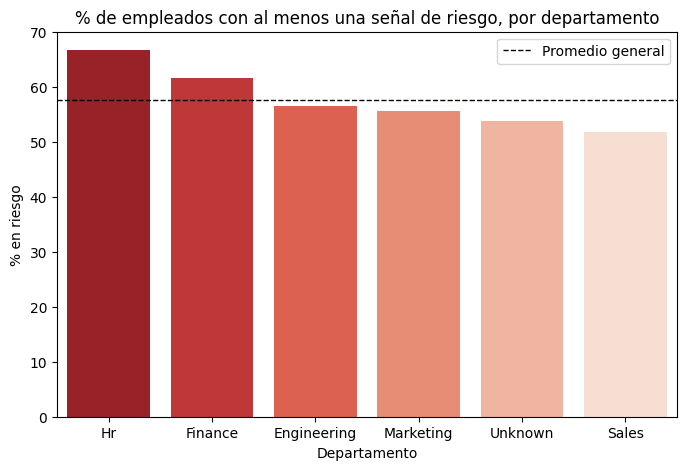

In [131]:
plt.figure(figsize=(8, 5))
sns.barplot(x=porcentaje_riesgo.index, y=porcentaje_riesgo.values, hue=porcentaje_riesgo.index, palette='Reds_r', legend=False)
plt.title('% de empleados con al menos una señal de riesgo, por departamento')
plt.ylabel('% en riesgo')
plt.xlabel('Departamento')
plt.axhline(porcentaje_riesgo.mean(), color='black', ls='--', lw=1, label='Promedio general')
plt.legend()
plt.show()

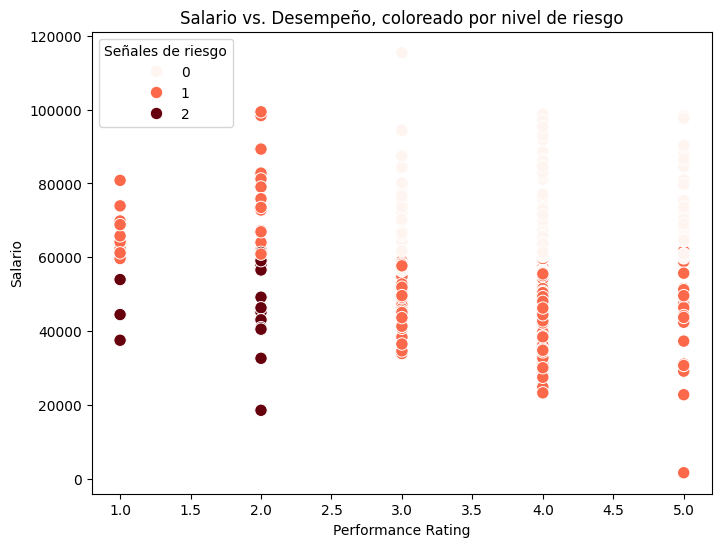

In [132]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=analytics_general,
    x='performance_rating',
    y='salary',
    hue='riesgo_total',
    palette='Reds',
    s=80
)
plt.title('Salario vs. Desempeño, coloreado por nivel de riesgo')
plt.xlabel('Performance Rating')
plt.ylabel('Salario')
plt.legend(title='Señales de riesgo')
plt.show()

In [133]:
desempeno_remoto = analytics_general.groupby('remote_work')['performance_rating'].mean().round(2)
desempeno_remoto

remote_work
No         3.49
Unknown    3.46
Yes        3.79
Name: performance_rating, dtype: float64

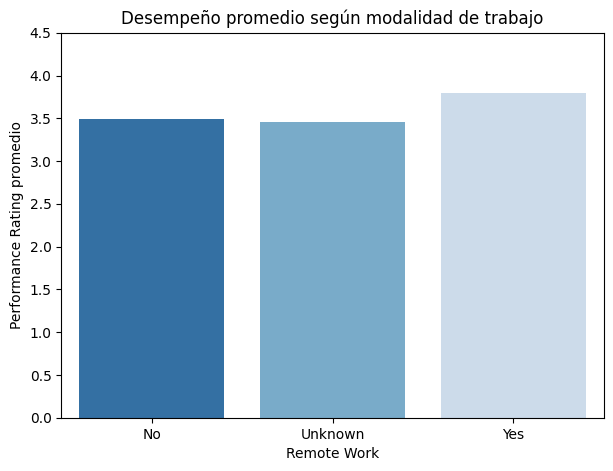

In [134]:
plt.figure(figsize=(7, 5))
sns.barplot(x=desempeno_remoto.index, y=desempeno_remoto.values, hue=desempeno_remoto.index, palette='Blues_r', legend=False)
plt.title('Desempeño promedio según modalidad de trabajo')
plt.ylabel('Performance Rating promedio')
plt.xlabel('Remote Work')
plt.ylim(0, 4.5)
plt.show()